
# **About Dataset**
## **Context**
This is a multivariate type of dataset which means providing or involving a variety of separate mathematical or statistical variables, multivariate numerical data analysis. It is composed of 14 attributes which are age, sex, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, exercise-induced angina, oldpeak — ST depression induced by exercise relative to rest, the slope of the peak exercise ST segment, number of major vessels and Thalassemia. This database includes 76 attributes, but all published studies relate to the use of a subset of 14 of them. The Cleveland database is the only one used by ML researchers to date. One of the major tasks on this dataset is to predict based on the given attributes of a patient that whether that particular person has heart disease or not and other is the experimental task to diagnose and find out various insights from this dataset which could help in understanding the problem more.

### **Content**
#### **Column Descriptions:**
* `id` (Unique id for each patient)
* `age` (Age of the patient in years)
* `dataset` (place of study)
* `sex` (Male/Female)
* `cp chest pain type `
  1. typical angina
  2.  atypical angina
  3.   non-anginal, asymptomatic
* `trestbps resting blood pressure` (resting blood pressure (in mm Hg on admission to the hospital))
* `chol `(serum cholesterol in mg/dl)
* `fbs` (if fasting blood sugar > 120 mg/dl)
* `restecg `(resting electrocardiographic results)
  * `- Values:` 
  1.  normal
  2. stt abnormality
  3.  lv hypertrophy
* `thalach:` maximum heart rate achieved
* `exang:` exercise-induced angina (True/ False)
* `oldpeak:` ST depression induced by exercise relative to rest
* `slope:` the slope of the peak exercise ST segment
* `ca:` number of major vessels (0-3) colored by fluoroscopy
* `thal:` 
   1. normal
   2.  fixed defect
   3.   reversible defect   
* `num:` the predicted attribute



### **Import Libararies**

In [116]:
# Step 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pickle

## **Load the Dataset**

In [117]:
# Step 2 - Load Data
df = pd.read_csv(r'C:\Users\patni\OneDrive\Documents\Heart Disease\data\heart_disease_uci.csv')


## **Exploratory Data Analysis(EDA)**

In [118]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [119]:
df = df.drop('dataset', axis=1)  # Dropping unnecessary column

In [120]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     865 non-null    object 
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(7)
memory usage: 107.9+ KB


In [121]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [122]:
df.isnull().sum()

id            0
age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [123]:
df = df.drop(['id', 'slope', 'ca', 'thal'], axis=1) #have too many missing values 50%, 85%, 67% .


In [124]:
# Median for numeric columns
df['trestbps'].fillna(df['trestbps'].median(), inplace=True)
df['chol'].fillna(df['chol'].median(), inplace=True)
df['thalch'].fillna(df['thalch'].median(), inplace=True)
df['oldpeak'].fillna(df['oldpeak'].median(), inplace=True)

# Mode for categorical / binary columns
df['fbs'].fillna(df['fbs'].mode()[0], inplace=True)
df['restecg'].fillna(df['restecg'].mode()[0], inplace=True)
df['exang'].fillna(df['exang'].mode()[0], inplace=True)


C:\Users\patni\AppData\Local\Temp\ipykernel_12652\404721929.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\patni\AppData\Local\Temp\ipykernel_12652\404721929.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [125]:
# Step 3 - Clean Data
df.replace('?', np.nan, inplace=True)
df.drop_duplicates(inplace=True)


In [126]:
df.isnull().sum()


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
num         0
dtype: int64

In [127]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 919
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    int64  
 1   sex       918 non-null    object 
 2   cp        918 non-null    object 
 3   trestbps  918 non-null    float64
 4   chol      918 non-null    float64
 5   fbs       918 non-null    bool   
 6   restecg   918 non-null    object 
 7   thalch    918 non-null    float64
 8   exang     918 non-null    bool   
 9   oldpeak   918 non-null    float64
 10  num       918 non-null    int64  
dtypes: bool(2), float64(4), int64(2), object(3)
memory usage: 73.5+ KB


<Axes: xlabel='age', ylabel='Count'>

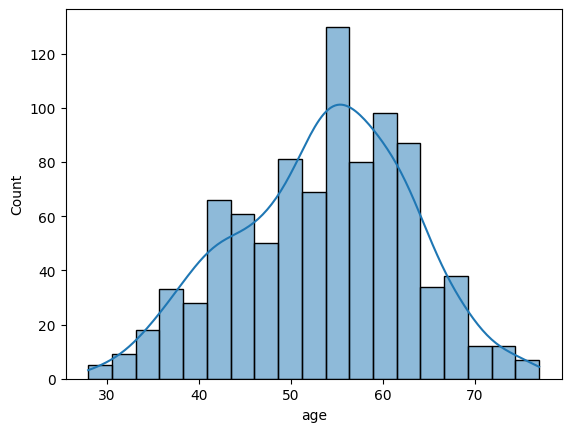

In [128]:
sns.histplot(df['age'], kde=True)

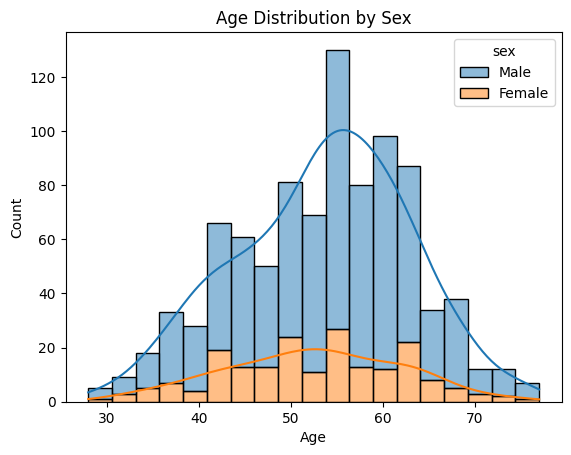

In [129]:
sns.histplot(data=df, x='age', hue='sex', multiple='stack', kde=True)
plt.title('Age Distribution by Sex')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

percentage_male is  274.23% more than female_percentage 

C:\Users\patni\AppData\Local\Temp\ipykernel_12652\2287406571.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




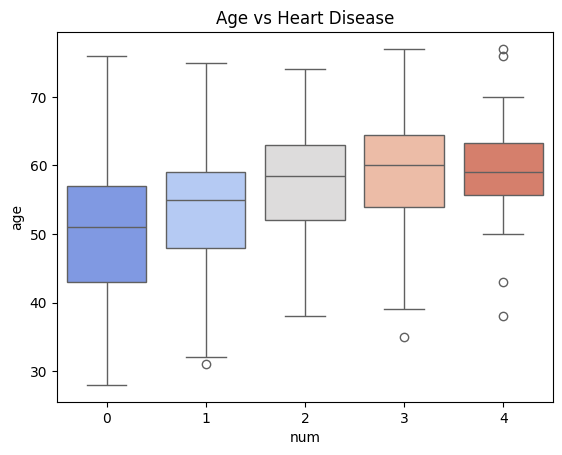

In [130]:
# Age vs Heart Disease
sns.boxplot(x='num', y='age', data=df, palette='coolwarm')
plt.title('Age vs Heart Disease')
plt.show()


Most of the people get the Heart Disease at the age of 53-54 according to this Dataset

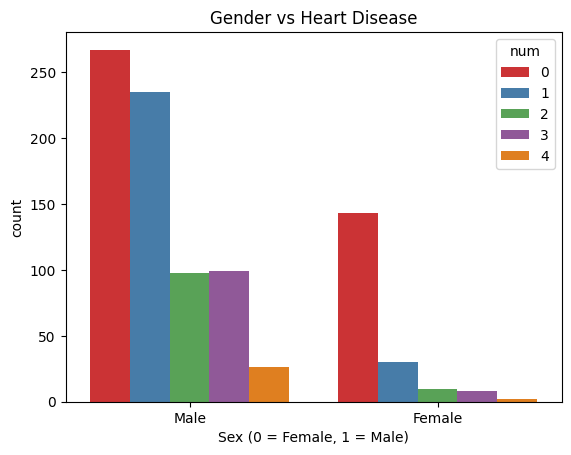

In [131]:
# Gender vs Heart Disease
sns.countplot(x='sex', hue='num', data=df, palette='Set1')
plt.title('Gender vs Heart Disease')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.show()

### **Lets Explore the cp(chest pain)column**

In [132]:
df['cp'].value_counts()

cp
asymptomatic       496
non-anginal        203
atypical angina    173
typical angina      46
Name: count, dtype: int64

C:\Users\patni\AppData\Local\Temp\ipykernel_12652\477459474.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




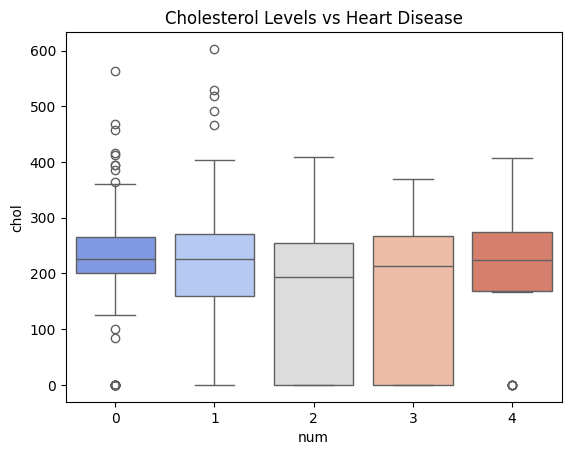

In [133]:
sns.boxplot(x='num', y='chol', data=df, palette='coolwarm')
plt.title('Cholesterol Levels vs Heart Disease')
plt.show()


C:\Users\patni\AppData\Local\Temp\ipykernel_12652\552387831.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




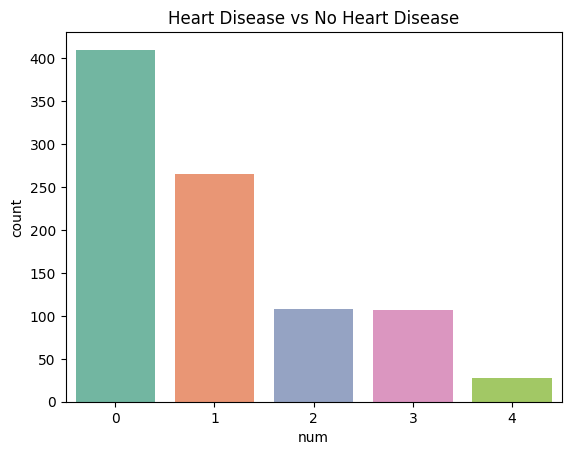

In [134]:
# Distribution of Target Variable
sns.countplot(x='num', data=df, palette='Set2')
plt.title('Heart Disease vs No Heart Disease')
plt.show()

In [135]:
# Step 4 - Create Target Column
df['target'] = df['num'].apply(lambda x: 0 if x == 0 else 1)
df.drop(columns=['num'], inplace=True, errors='ignore')

In [136]:
# Step 5 - One-hot Encoding for categorical cols
categorical_cols = ['cp', 'restecg']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [137]:
# Step 6 - Scale numerical features
scaler = StandardScaler()
num_features = ['age','trestbps','chol','thalch','oldpeak']
df[num_features] = scaler.fit_transform(df[num_features])

In [138]:
df.head()

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,target,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality
0,1.006537,Male,0.705085,0.303747,True,0.489681,False,1.365834,0,False,False,True,False,False
1,1.430829,Male,1.518645,0.789562,False,-1.180980,True,0.609600,1,False,False,False,False,False
2,1.430829,Male,-0.650848,0.267081,False,-0.345649,True,1.649422,1,False,False,False,False,False
3,-1.751359,Male,-0.108475,0.459574,False,1.961454,False,2.500185,0,False,True,False,True,False
4,-1.327067,Female,-0.108475,0.037923,False,1.364789,False,0.515071,0,True,False,False,False,False


In [139]:
df.shape


(918, 14)

In [141]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 919
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       918 non-null    float64
 1   sex                       918 non-null    object 
 2   trestbps                  918 non-null    float64
 3   chol                      918 non-null    float64
 4   fbs                       918 non-null    bool   
 5   thalch                    918 non-null    float64
 6   exang                     918 non-null    bool   
 7   oldpeak                   918 non-null    float64
 8   target                    918 non-null    int64  
 9   cp_atypical angina        918 non-null    bool   
 10  cp_non-anginal            918 non-null    bool   
 11  cp_typical angina         918 non-null    bool   
 12  restecg_normal            918 non-null    bool   
 13  restecg_st-t abnormality  918 non-null    bool   
dtypes: bool(7), flo

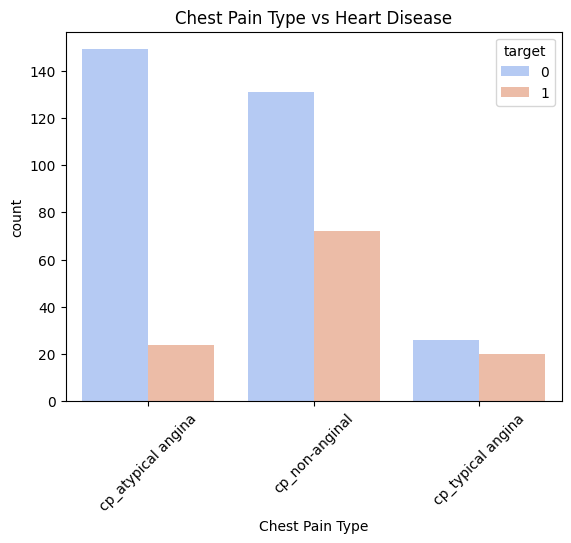

In [142]:
cp_cols = [col for col in df.columns if col.startswith('cp_')]
cp_data = df[cp_cols + ['target']].melt(id_vars='target', var_name='Chest Pain Type', value_name='Present')
sns.countplot(x='Chest Pain Type', hue='target', data=cp_data[cp_data['Present']], palette='coolwarm')
plt.title('Chest Pain Type vs Heart Disease')
plt.xticks(rotation=45)
plt.show()


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 919
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       918 non-null    float64
 1   sex                       918 non-null    object 
 2   trestbps                  918 non-null    float64
 3   chol                      918 non-null    float64
 4   fbs                       918 non-null    bool   
 5   thalch                    918 non-null    float64
 6   exang                     918 non-null    bool   
 7   oldpeak                   918 non-null    float64
 8   target                    918 non-null    int64  
 9   cp_atypical angina        918 non-null    bool   
 10  cp_non-anginal            918 non-null    bool   
 11  cp_typical angina         918 non-null    bool   
 12  restecg_normal            918 non-null    bool   
 13  restecg_st-t abnormality  918 non-null    bool   
dtypes: bool(7), flo

In [144]:
# Convert 'sex' to numeric
df['sex'] = df['sex'].replace({'Male': 1, 'M': 1, 'Female': 0, 'F': 0})
df['sex'] = df['sex'].astype(int)


C:\Users\patni\AppData\Local\Temp\ipykernel_12652\1992763792.py:2: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



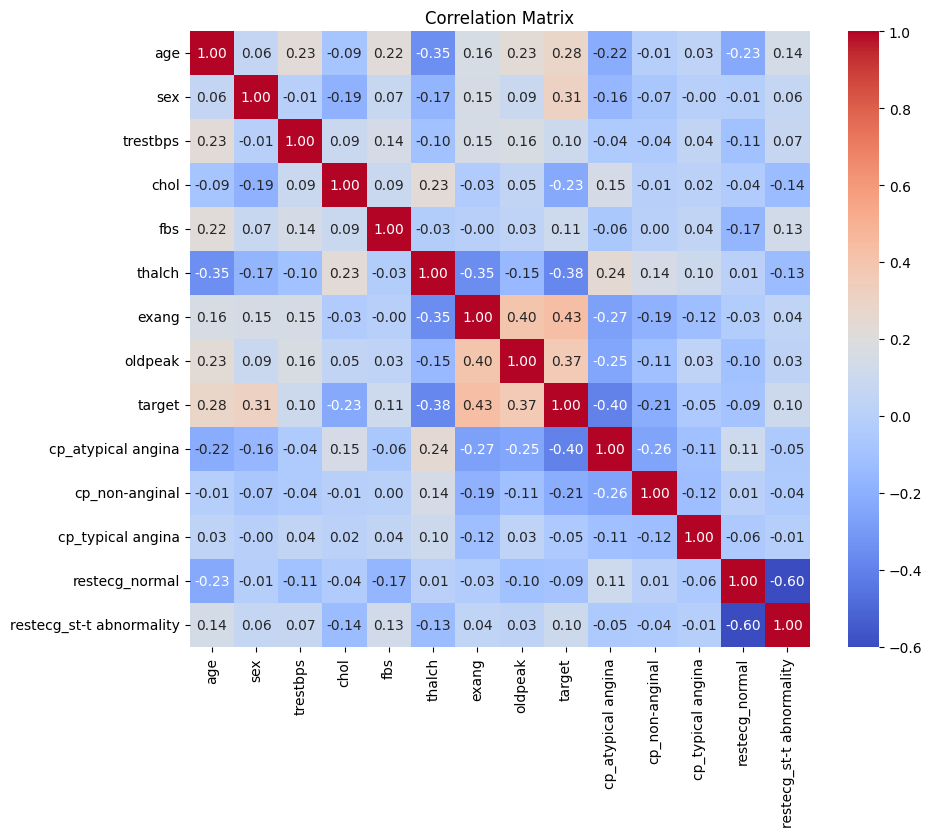

In [145]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


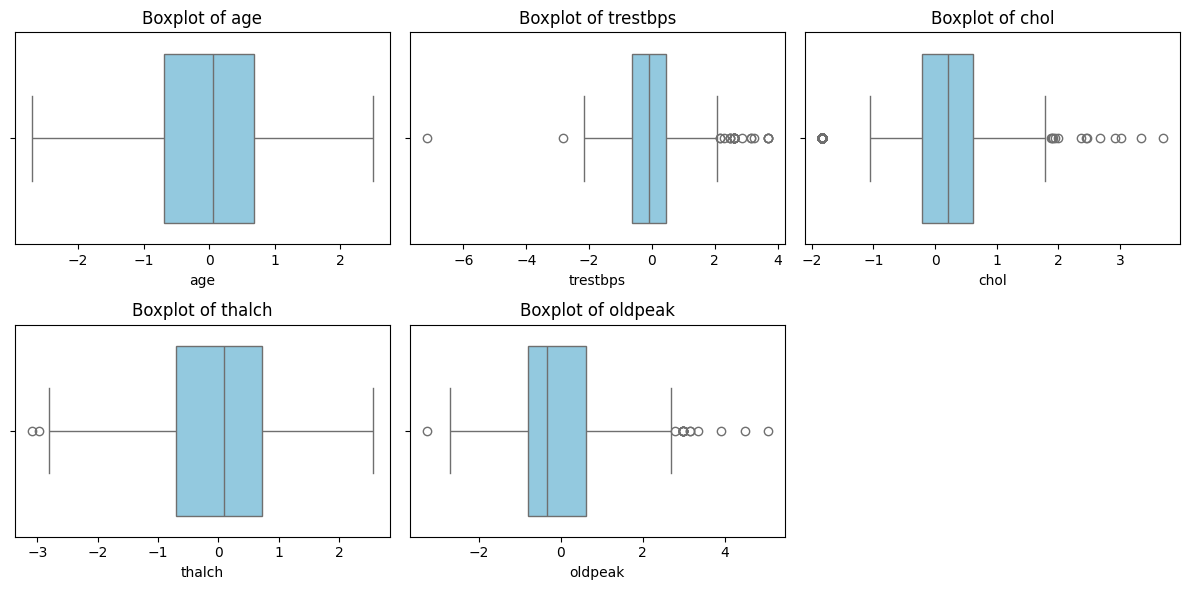

In [146]:
numeric_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


In [147]:
print(df.shape)

(918, 14)


In [148]:
def cap_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = df[col].clip(lower, upper)
    return df


In [149]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
df = cap_outliers(df, numeric_cols)



In [150]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    print(f"{col}: Min={df[col].min()}, Max={df[col].max()}, Range=({lower:.2f}, {upper:.2f})")


age: Min=-2.7060147534137067, Max=2.491557971213961, Range=(-2.76, 2.76)
trestbps: Min=-2.277966871577558, Max=2.0610176457130285, Range=(-2.28, 2.06)
chol: Min=-1.4412912464264493, Max=1.8494170828266623, Range=(-1.44, 1.85)
thalch: Min=-2.836724248520433, Max=2.55811827316769, Range=(-2.84, 2.85)
oldpeak: Min=-2.935246111984294, Max=2.7365081714079147, Range=(-2.94, 2.74)


In [151]:
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 919
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       918 non-null    float64
 1   sex                       918 non-null    int32  
 2   trestbps                  918 non-null    float64
 3   chol                      918 non-null    float64
 4   fbs                       918 non-null    bool   
 5   thalch                    918 non-null    float64
 6   exang                     918 non-null    bool   
 7   oldpeak                   918 non-null    float64
 8   target                    918 non-null    int64  
 9   cp_atypical angina        918 non-null    bool   
 10  cp_non-anginal            918 non-null    bool   
 11  cp_typical angina         918 non-null    bool   
 12  restecg_normal            918 non-null    bool   
 13  restecg_st-t abnormality  918 non-null    bool   
dtypes: bool(7), flo

In [154]:
# Step 7 - Split train/test
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.to_csv(r'C:\Users\patni\OneDrive\Documents\Heart Disease\data\X_train.csv', index=False)
X_test.to_csv(r'C:\Users\patni\OneDrive\Documents\Heart Disease\data\X_test.csv', index=False)
y_train.to_csv(r'C:\Users\patni\OneDrive\Documents\Heart Disease\data\y_train.csv', index=False)
y_test.to_csv(r'C:\Users\patni\OneDrive\Documents\Heart Disease\data\y_test.csv', index=False)


In [153]:
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
